시험에서 라벨 스무딩 나옴, 템퍼레쳐 어쩌고는 안나옴

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_gray = cv2.imread('/home/lyj/Downloads/두산로보틱스자료/강의자료/AI/응용/data/copy.png', cv2.IMREAD_GRAYSCALE)

In [4]:
import os
os.getcwd()

'/home/lyj/study_archive/bootcamp/AI/intermediate/ch03'

In [19]:
# 각 픽셀의 주변 블록(11×11) 내 가우시안 가중 평균을 임계값으로 사용
# C=2: 평균에서 뺄 보정 상수 (노이즈 억제)
thresh_adaptive = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,   # 홀수여야 함
    C=4
)

# Step 1: 히스토그램 평활화 → 픽셀 분포를 0~255 전체로 균등하게 펼침
img_equalized = cv2.equalizeHist(img_gray)

# Step 2: Otsu 방법으로 전역 임계값 자동 결정
# THRESH_OTSU: 클래스 내 분산이 최소가 되는 임계값을 자동 탐색
otsu_val, thresh_equalized = cv2.threshold(
    img_equalized, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"Otsu 자동 임계값: {otsu_val:.0f}")  # 테스트 이미지 기준 175

Otsu 자동 임계값: 139


In [ ]:


# A. CLAHE
# 1. clipLimit: 히스토그램 클리핑 임계값 (높을수록 대비 강함, 노이즈 증폭 위험)
# tileGridSize: 타일 분할 크기 (작을수록 더 지역적으로 처리)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

_, thresh_clahe = cv2.threshold(
    img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# B. 가우시안 블러 전처리 후 Otsu
# 블러로 노이즈 제거 후 평활화 → Otsu 순서 적용
img_blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
img_eq_blur = cv2.equalizeHist(img_blurred)
_, thresh_blur_eq = cv2.threshold(
    img_eq_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# C. CLAHE + adaptiveThreshold 조합
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)
# 개선된 명암 대비 위에서 지역 이진화 적용
thresh_combined = cv2.adaptiveThreshold(
    img_clahe, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11, C=4
)

Otsu 자동 임계값: 139


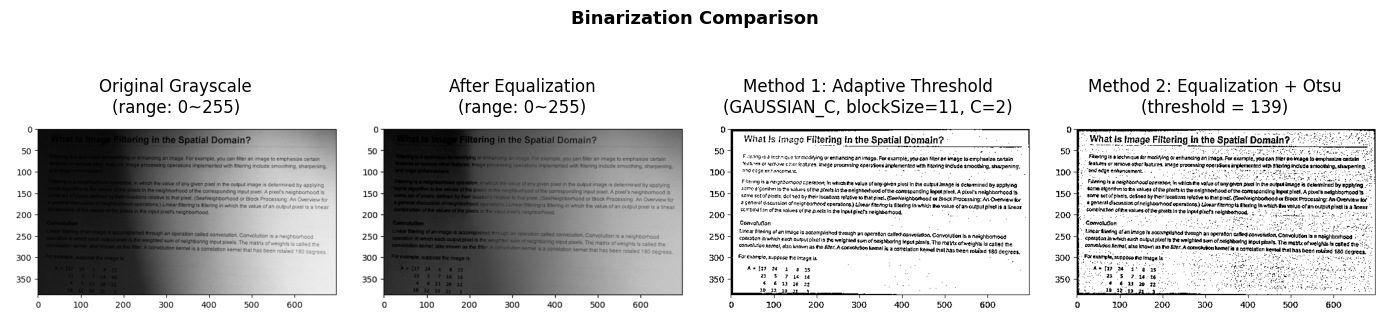

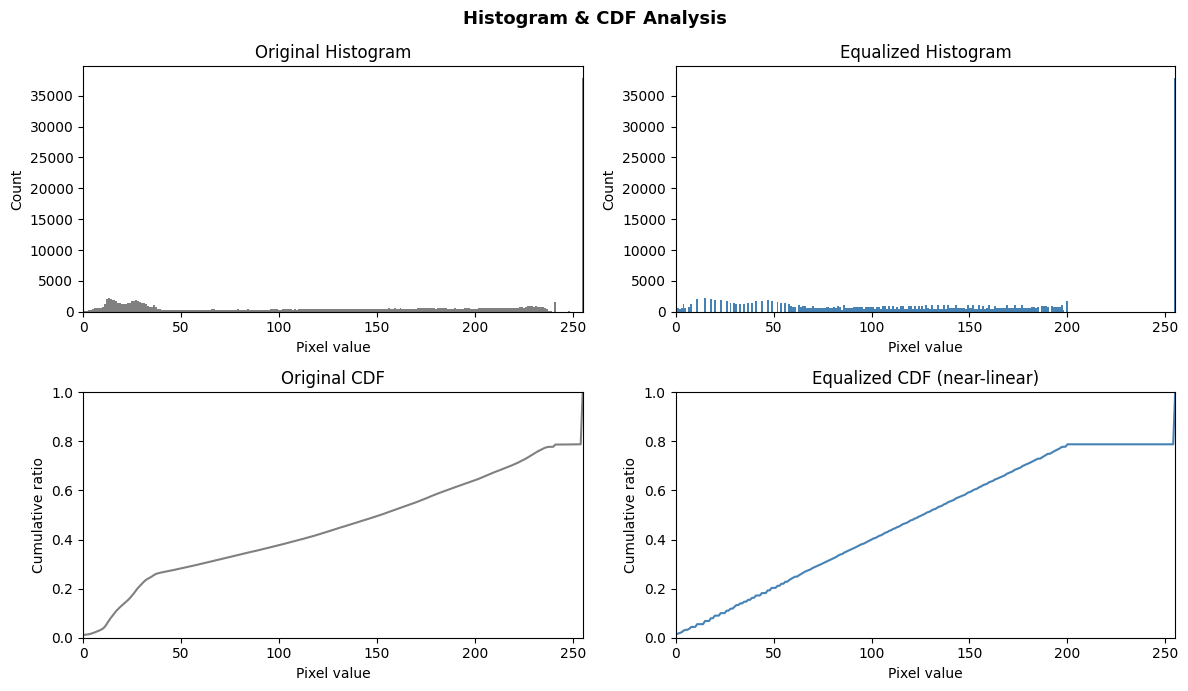

In [18]:
# ════════════════════════════════════════════════════════════════
# 결과 이미지 시각화
# ════════════════════════════════════════════════════════════════

# ── Figure 1: 이진화 결과 이미지 비교 ────────────────────────────
plt.figure(figsize=(14, 4))

# 원본
plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.title(f'Original Grayscale\n(range: {img_gray.min()}~{img_gray.max()})')
plt.axis('off')

# 평활화 후 이미지 (이진화 전 중간 결과 확인용)
plt.subplot(1, 4, 2)
plt.imshow(img_equalized, cmap='gray', vmin=0, vmax=255)
plt.title(f'After Equalization\n(range: {img_equalized.min()}~{img_equalized.max()})')
plt.axis('off')

# 방법 1: adaptiveThreshold 결과
plt.subplot(1, 4, 3)
plt.imshow(thresh_adaptive, cmap='gray', vmin=0, vmax=255)
plt.title('Method 1: Adaptive Threshold\n(GAUSSIAN_C, blockSize=11, C=2)')
plt.axis('off')

# 방법 2: 히스토그램 평활화 + Otsu 결과
plt.subplot(1, 4, 4)
plt.imshow(thresh_combined, cmap='gray', vmin=0, vmax=255)
plt.title(f'Method 2: Equalization + Otsu\n(threshold = {otsu_val:.0f})')
plt.axis('off')

plt.suptitle('Binarization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 2: 히스토그램 & CDF 비교 ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Histogram & CDF Analysis', fontsize=13, fontweight='bold')

# 원본 히스토그램
hist_orig = cv2.calcHist([img_gray],      [0], None, [256], [0, 256]).flatten()
hist_eq   = cv2.calcHist([img_equalized], [0], None, [256], [0, 256]).flatten()
x = np.arange(256)
cdf_orig = hist_orig.cumsum() / hist_orig.sum()
cdf_eq   = hist_eq.cumsum()   / hist_eq.sum()

axes[0][0].bar(x, hist_orig, color='gray', width=1)
axes[0][0].set_title('Original Histogram')
axes[0][0].set_xlabel('Pixel value')
axes[0][0].set_ylabel('Count')
axes[0][0].set_xlim([0, 255])

axes[0][1].bar(x, hist_eq, color='steelblue', width=1)
axes[0][1].set_title('Equalized Histogram')
axes[0][1].set_xlabel('Pixel value')
axes[0][1].set_ylabel('Count')
axes[0][1].set_xlim([0, 255])

# CDF: 평활화가 잘 됐을수록 선형(대각선)에 가까워짐
axes[1][0].plot(x, cdf_orig, color='gray')
axes[1][0].set_title('Original CDF')
axes[1][0].set_xlabel('Pixel value')
axes[1][0].set_ylabel('Cumulative ratio')
axes[1][0].set_xlim([0, 255]); axes[1][0].set_ylim([0, 1])

axes[1][1].plot(x, cdf_eq, color='steelblue')
axes[1][1].set_title('Equalized CDF (near-linear)')
axes[1][1].set_xlabel('Pixel value')
axes[1][1].set_ylabel('Cumulative ratio')
axes[1][1].set_xlim([0, 255]); axes[1][1].set_ylim([0, 1])

plt.tight_layout()
plt.show()